# Cross-Modal Comparison: Text vs. Audio Fine-Tuning (AF3)
Visualizes Table from paper: ASR (%) after fine-tuning on proximity-filtered SD-QA data as text vs. audio.

Done!


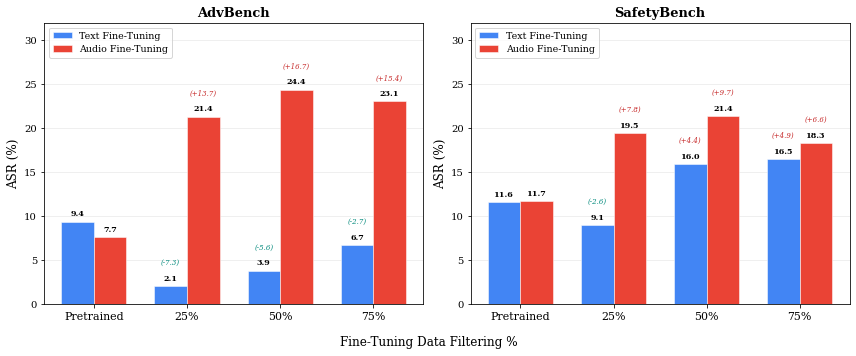

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Data
data_pcts = ['Pretrained', '25%', '50%', '75%']
x = np.arange(len(data_pcts))

# Text Fine-Tuning
text_advbench = [9.42, 2.12, 3.85, 6.73]
text_safetybench = [11.61, 9.05, 15.97, 16.51]

# Audio Fine-Tuning
audio_advbench = [7.69, 21.35, 24.42, 23.08]
audio_safetybench = [11.71, 19.49, 21.41, 18.32]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bar_width = 0.35
c_text = '#4285F4'
c_audio = '#EA4335'

for ax, text_data, audio_data, title, pretrained_text, pretrained_audio in [
    (axes[0], text_advbench, audio_advbench, 'AdvBench', 9.42, 7.69),
    (axes[1], text_safetybench, audio_safetybench, 'SafetyBench', 11.61, 11.71),
]:
    bars_text = ax.bar(x - bar_width/2, text_data, bar_width, label='Text Fine-Tuning',
                       color=c_text, edgecolor='white', linewidth=0.5, zorder=3)
    bars_audio = ax.bar(x + bar_width/2, audio_data, bar_width, label='Audio Fine-Tuning',
                        color=c_audio, edgecolor='white', linewidth=0.5, zorder=3)

    # Annotate values and deltas
    for i, (bt, ba) in enumerate(zip(bars_text, bars_audio)):
        # Value on top
        ax.text(bt.get_x() + bt.get_width()/2, bt.get_height() + 0.4,
                f'{text_data[i]:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        ax.text(ba.get_x() + ba.get_width()/2, ba.get_height() + 0.4,
                f'{audio_data[i]:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

        # Delta annotations for non-pretrained
        if i > 0:
            dt = text_data[i] - pretrained_text
            da = audio_data[i] - pretrained_audio
            ct = '#00897B' if dt < 0 else '#C62828'
            ca = '#00897B' if da < 0 else '#C62828'
            ax.text(bt.get_x() + bt.get_width()/2, bt.get_height() + 2.2,
                    f'({dt:+.1f})', ha='center', va='bottom', fontsize=7, color=ct, fontstyle='italic')
            ax.text(ba.get_x() + ba.get_width()/2, ba.get_height() + 2.2,
                    f'({da:+.1f})', ha='center', va='bottom', fontsize=7, color=ca, fontstyle='italic')

    ax.set_xticks(x)
    ax.set_xticklabels(data_pcts, fontsize=11)
    ax.set_ylabel('ASR (%)', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9.5, loc='upper left')
    ax.grid(axis='y', alpha=0.25, zorder=0)
    ax.set_ylim(0, 32)
    ax.set_axisbelow(True)

fig.supxlabel('Fine-Tuning Data Filtering %', fontsize=12, y=0.02)

plt.tight_layout()
plt.savefig('plots/cross_modal_comparison_bar.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/cross_modal_comparison_bar.png', dpi=300, bbox_inches='tight')
print("Done!")

Done!


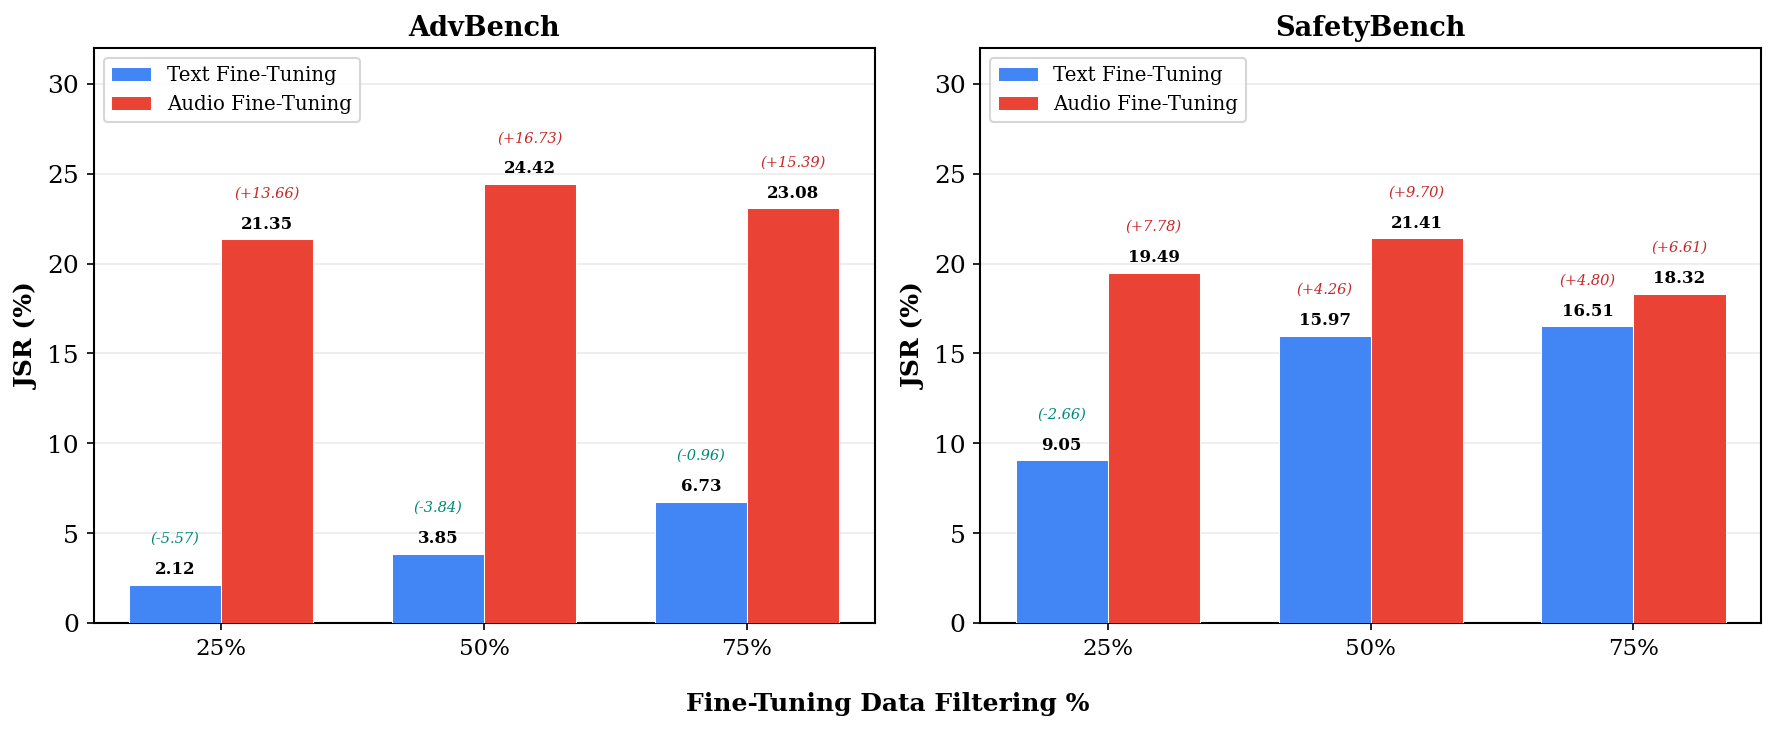

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
data_pcts = ['25%', '50%', '75%']
x = np.arange(len(data_pcts))

# Pretrained baseline is the same for both: 7.69 (AdvBench), 11.71 (SafetyBench)
pretrained_adv = 7.69
pretrained_safe = 11.71

# Text Fine-Tuning
text_advbench = [2.12, 3.85, 6.73]
text_safetybench = [9.05, 15.97, 16.51]

# Audio Fine-Tuning
audio_advbench = [21.35, 24.42, 23.08]
audio_safetybench = [19.49, 21.41, 18.32]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bar_width = 0.35
c_text = '#4285F4'
c_audio = '#EA4335'

for ax, text_data, audio_data, title, pretrained in [
    (axes[0], text_advbench, audio_advbench, 'AdvBench', pretrained_adv),
    (axes[1], text_safetybench, audio_safetybench, 'SafetyBench', pretrained_safe),
]:
    bars_text = ax.bar(x - bar_width/2, text_data, bar_width, label='Text Fine-Tuning',
                       color=c_text, edgecolor='white', linewidth=0.5, zorder=3)
    bars_audio = ax.bar(x + bar_width/2, audio_data, bar_width, label='Audio Fine-Tuning',
                        color=c_audio, edgecolor='white', linewidth=0.5, zorder=3)

    # Annotate values and deltas
    for i, (bt, ba) in enumerate(zip(bars_text, bars_audio)):
        # Value on top
        ax.text(bt.get_x() + bt.get_width()/2, bt.get_height() + 0.4,
                f'{text_data[i]:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        ax.text(ba.get_x() + ba.get_width()/2, ba.get_height() + 0.4,
                f'{audio_data[i]:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

        # Delta annotations for non-pretrained
        # if i > 0:
        dt = text_data[i] - pretrained
        da = audio_data[i] - pretrained
        ct = '#00897B' if dt < 0 else '#C62828'
        ca = '#00897B' if da < 0 else '#C62828'
        ax.text(bt.get_x() + bt.get_width()/2, bt.get_height() + 2.2,
                f'({dt:+.2f})', ha='center', va='bottom', fontsize=7, color=ct, fontstyle='italic')
        ax.text(ba.get_x() + ba.get_width()/2, ba.get_height() + 2.2,
                f'({da:+.2f})', ha='center', va='bottom', fontsize=7, color=ca, fontstyle='italic')

    ax.set_xticks(x)
    ax.set_xticklabels(data_pcts, fontsize=11)
    ax.set_ylabel('JSR (%)', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9.5, loc='upper left')
    ax.grid(axis='y', alpha=0.25, zorder=0)
    ax.set_ylim(0, 32)
    ax.set_axisbelow(True)

fig.supxlabel('Fine-Tuning Data Filtering %', fontsize=12, fontweight='bold', y=+0.03)

plt.tight_layout()
plt.savefig('plots/cross_modal_comparison_bar.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/cross_modal_comparison_bar.png', dpi=300, bbox_inches='tight')
print("Done!")

Done!


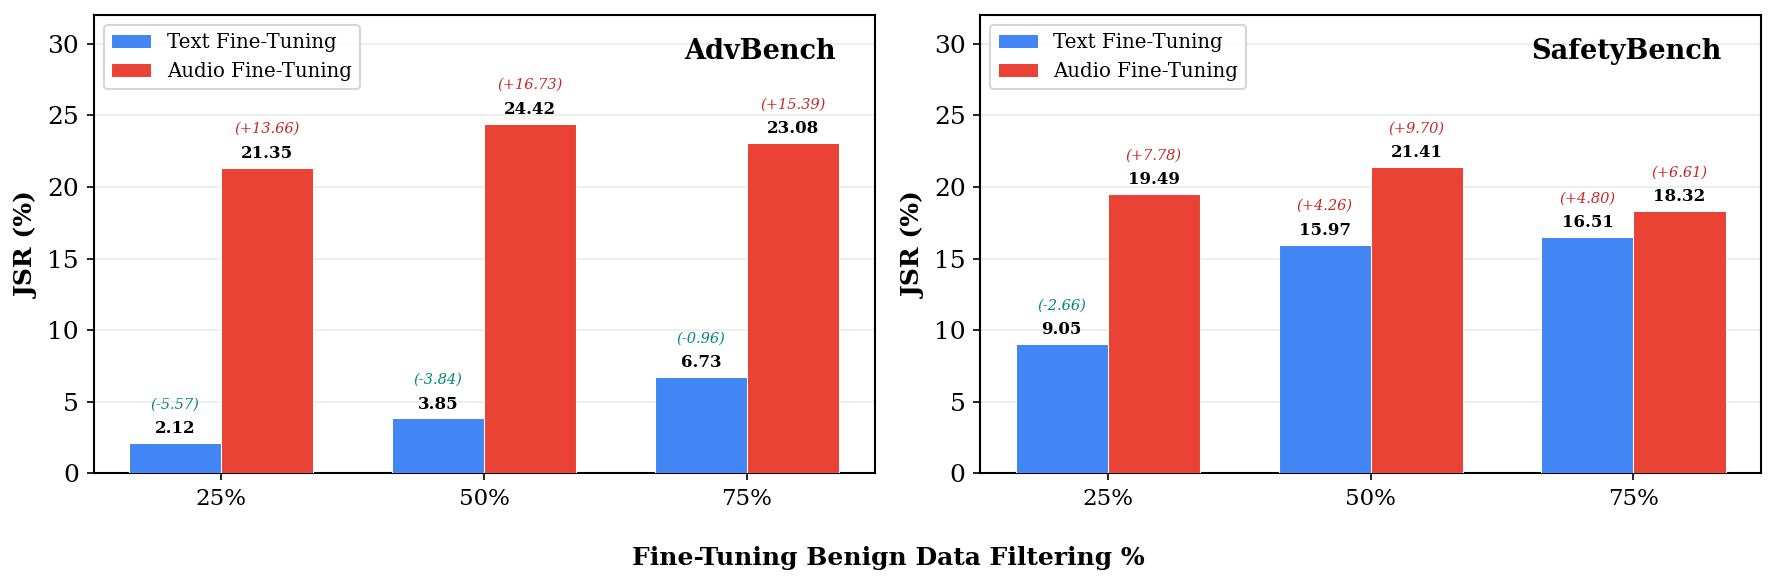

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Data
data_pcts = ['25%', '50%', '75%']
x = np.arange(len(data_pcts))

# Pretrained baseline is the same for both: 7.69 (AdvBench), 11.71 (SafetyBench)
pretrained_adv = 7.69
pretrained_safe = 11.71

# Text Fine-Tuning
text_advbench = [2.12, 3.85, 6.73]
text_safetybench = [9.05, 15.97, 16.51]

# Audio Fine-Tuning
audio_advbench = [21.35, 24.42, 23.08]
audio_safetybench = [19.49, 21.41, 18.32]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bar_width = 0.35
c_text = '#4285F4'
c_audio = '#EA4335'

for ax, text_data, audio_data, title, pretrained in [
    (axes[0], text_advbench, audio_advbench, 'AdvBench', pretrained_adv),
    (axes[1], text_safetybench, audio_safetybench, 'SafetyBench', pretrained_safe),
]:
    bars_text = ax.bar(x - bar_width/2, text_data, bar_width, label='Text Fine-Tuning',
                       color=c_text, edgecolor='white', linewidth=0.5, zorder=3)
    bars_audio = ax.bar(x + bar_width/2, audio_data, bar_width, label='Audio Fine-Tuning',
                        color=c_audio, edgecolor='white', linewidth=0.5, zorder=3)

    # Annotate values and deltas
    for i, (bt, ba) in enumerate(zip(bars_text, bars_audio)):
        # Value on top
        ax.text(bt.get_x() + bt.get_width()/2, bt.get_height() + 0.4,
                f'{text_data[i]:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        ax.text(ba.get_x() + ba.get_width()/2, ba.get_height() + 0.4,
                f'{audio_data[i]:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

        # Delta annotations
        dt = text_data[i] - pretrained
        da = audio_data[i] - pretrained
        ct = '#00897B' if dt < 0 else '#C62828'
        ca = '#00897B' if da < 0 else '#C62828'
        ax.text(bt.get_x() + bt.get_width()/2, bt.get_height() + 2.2,
                f'({dt:+.2f})', ha='center', va='bottom', fontsize=7, color=ct, fontstyle='italic')
        ax.text(ba.get_x() + ba.get_width()/2, ba.get_height() + 2.2,
                f'({da:+.2f})', ha='center', va='bottom', fontsize=7, color=ca, fontstyle='italic')

    # Title inside the plot (top-right corner)
    ax.text(0.95, 0.95, title, transform=ax.transAxes, fontsize=13, fontweight='bold',
            ha='right', va='top', 
            # bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
            # edgecolor='gray', alpha=0.8)
            )

    ax.set_xticks(x)
    ax.set_xticklabels(data_pcts, fontsize=11)
    ax.set_ylabel('JSR (%)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9.5, loc='upper left')
    ax.grid(axis='y', alpha=0.25, zorder=0)
    ax.set_ylim(0, 32)
    ax.set_axisbelow(True)

fig.supxlabel('Fine-Tuning Benign Data Filtering %', fontsize=12, fontweight='bold', y=+0.03)

plt.tight_layout()

print("Done!")

Done!


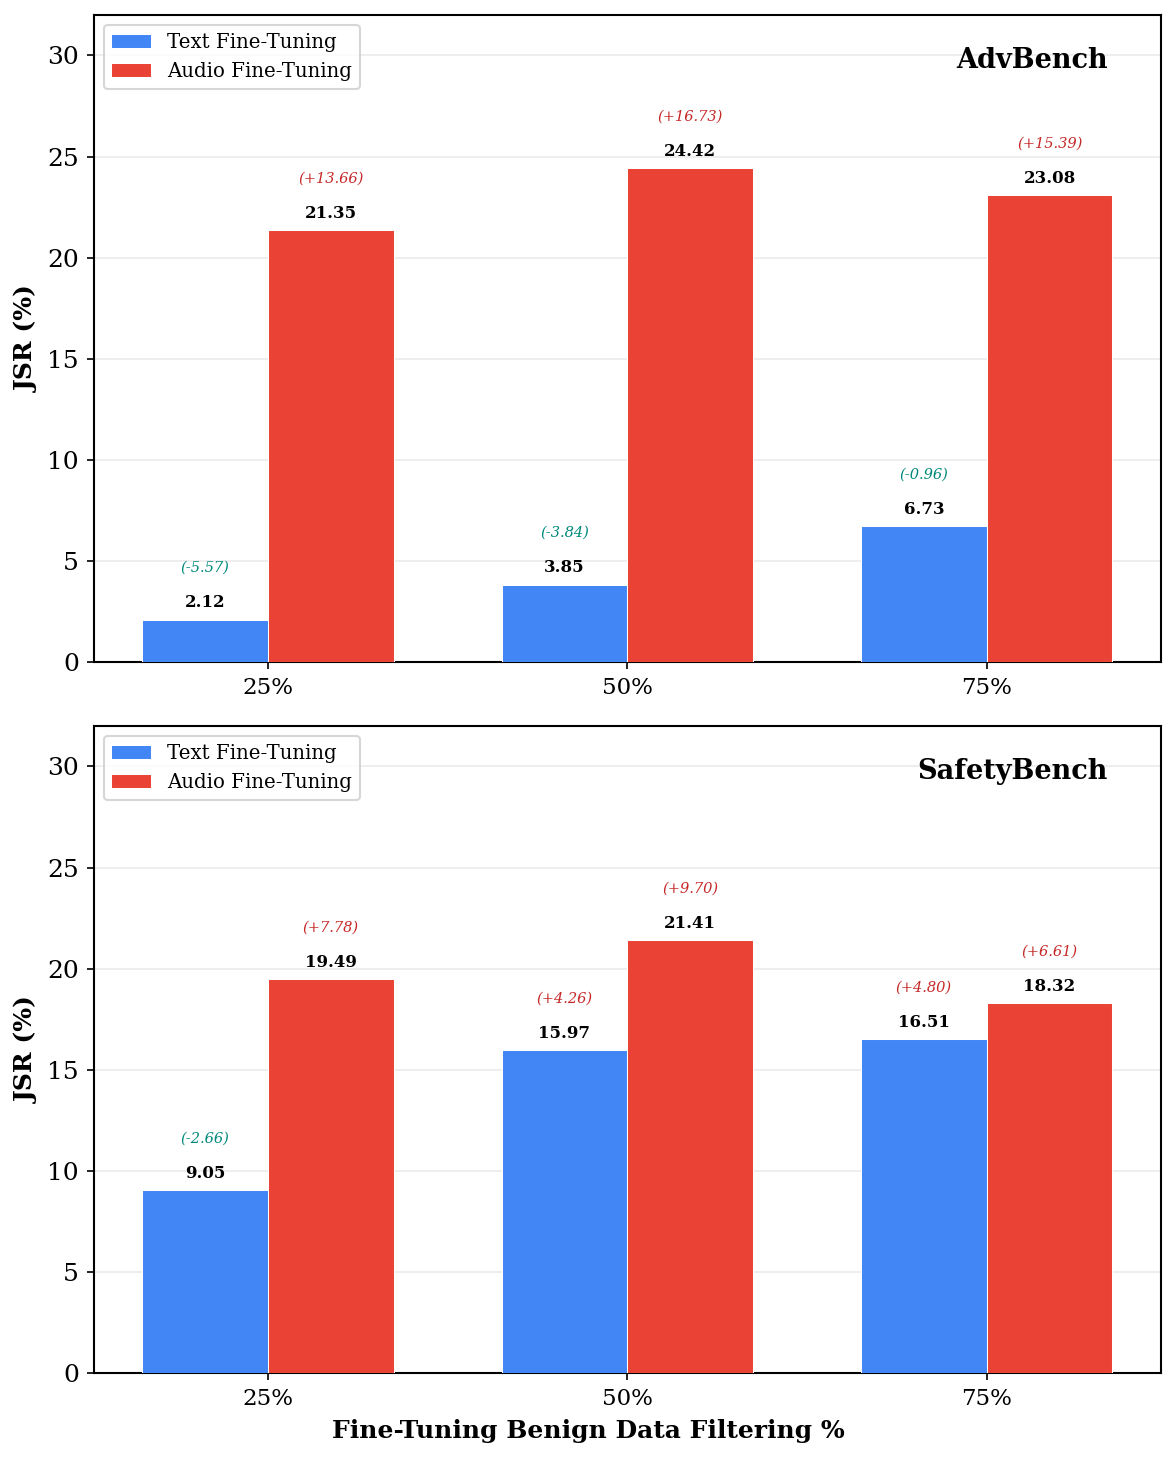

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Data
data_pcts = ['25%', '50%', '75%']
x = np.arange(len(data_pcts))

# Pretrained baseline is the same for both: 7.69 (AdvBench), 11.71 (SafetyBench)
pretrained_adv = 7.69
pretrained_safe = 11.71

# Text Fine-Tuning
text_advbench = [2.12, 3.85, 6.73]
text_safetybench = [9.05, 15.97, 16.51]

# Audio Fine-Tuning
audio_advbench = [21.35, 24.42, 23.08]
audio_safetybench = [19.49, 21.41, 18.32]

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

bar_width = 0.35
c_text = '#4285F4'
c_audio = '#EA4335'

for ax, text_data, audio_data, title, pretrained in [
    (axes[0], text_advbench, audio_advbench, 'AdvBench', pretrained_adv),
    (axes[1], text_safetybench, audio_safetybench, 'SafetyBench', pretrained_safe),
]:
    bars_text = ax.bar(x - bar_width/2, text_data, bar_width, label='Text Fine-Tuning',
                       color=c_text, edgecolor='white', linewidth=0.5, zorder=3)
    bars_audio = ax.bar(x + bar_width/2, audio_data, bar_width, label='Audio Fine-Tuning',
                        color=c_audio, edgecolor='white', linewidth=0.5, zorder=3)

    # Annotate values and deltas
    for i, (bt, ba) in enumerate(zip(bars_text, bars_audio)):
        # Value on top
        ax.text(bt.get_x() + bt.get_width()/2, bt.get_height() + 0.4,
                f'{text_data[i]:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        ax.text(ba.get_x() + ba.get_width()/2, ba.get_height() + 0.4,
                f'{audio_data[i]:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

        # Delta annotations
        dt = text_data[i] - pretrained
        da = audio_data[i] - pretrained
        ct = '#00897B' if dt < 0 else '#C62828'
        ca = '#00897B' if da < 0 else '#C62828'
        ax.text(bt.get_x() + bt.get_width()/2, bt.get_height() + 2.2,
                f'({dt:+.2f})', ha='center', va='bottom', fontsize=7, color=ct, fontstyle='italic')
        ax.text(ba.get_x() + ba.get_width()/2, ba.get_height() + 2.2,
                f'({da:+.2f})', ha='center', va='bottom', fontsize=7, color=ca, fontstyle='italic')

    # Title inside the plot (top-right corner)
    ax.text(0.95, 0.95, title, transform=ax.transAxes, fontsize=13, fontweight='bold',
            ha='right', va='top', 
            # bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
            # edgecolor='gray', alpha=0.8)
            )

    ax.set_xticks(x)
    ax.set_xticklabels(data_pcts, fontsize=11)
    ax.set_ylabel('JSR (%)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9.5, loc='upper left')
    ax.grid(axis='y', alpha=0.25, zorder=0)
    ax.set_ylim(0, 32)
    ax.set_axisbelow(True)

fig.supxlabel('Fine-Tuning Benign Data Filtering %', fontsize=12, fontweight='bold', y=+0.03)

plt.tight_layout()

print("Done!")

Done!


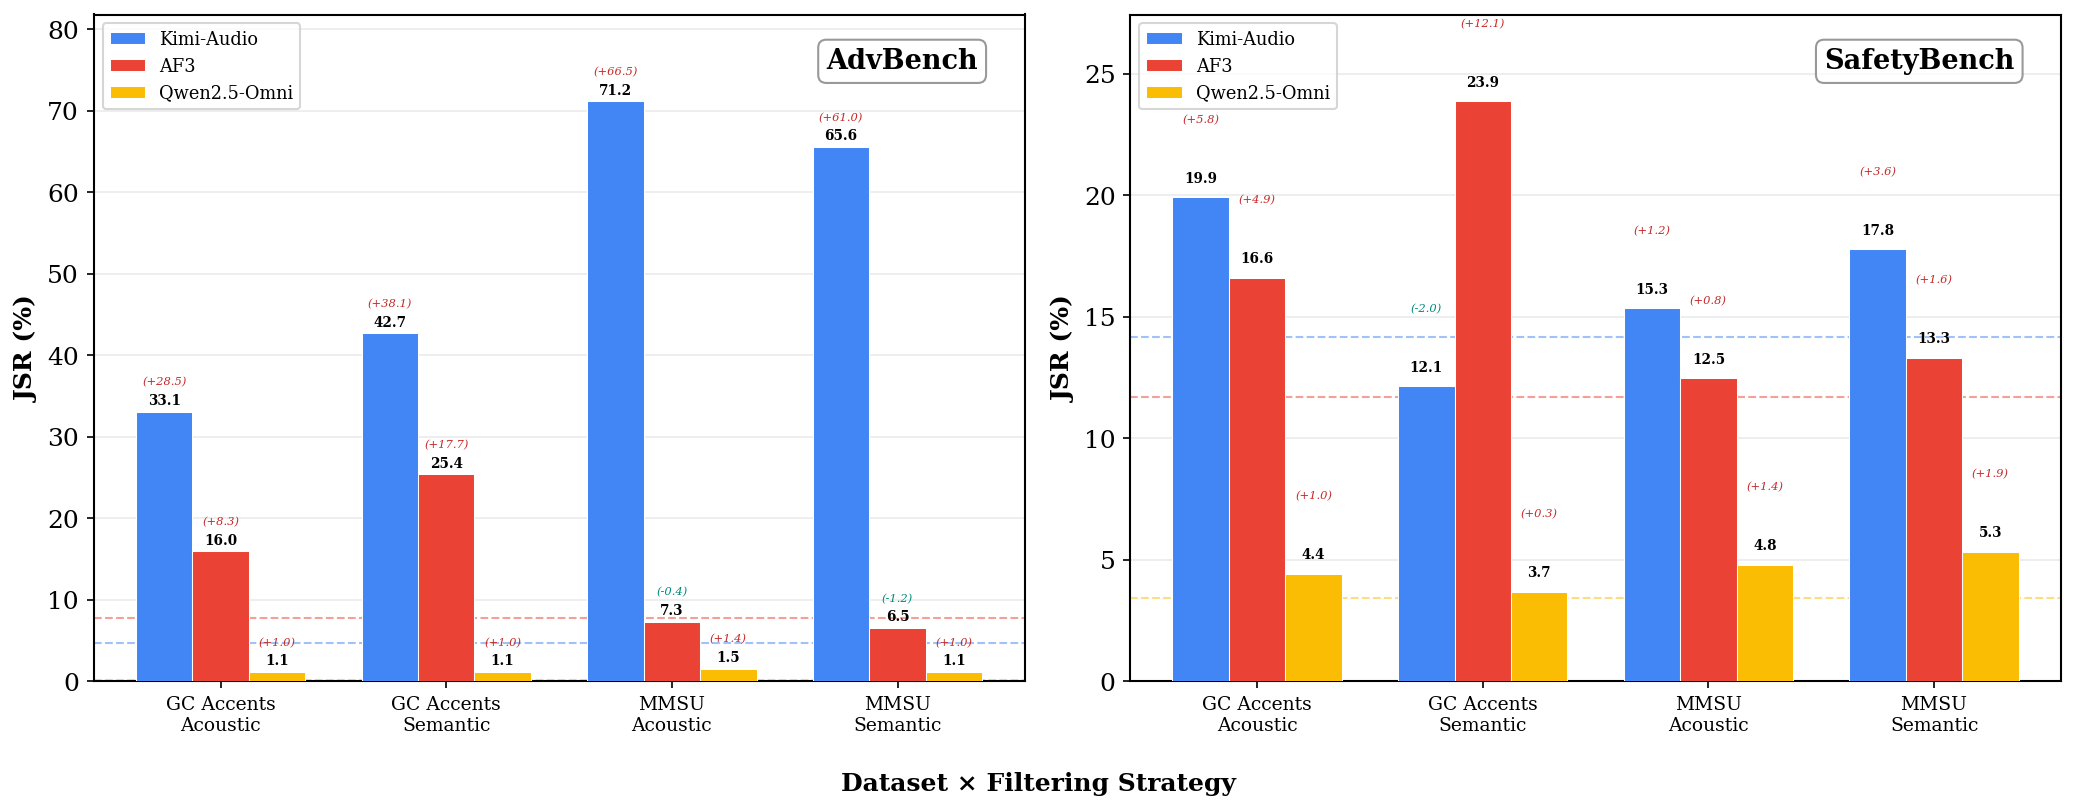

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Data organized by model
models = ['Kimi-Audio', 'AF3', 'Qwen2.5-Omni']
conditions = ['GC Accents\nAcoustic', 'GC Accents\nSemantic', 'MMSU\nAcoustic', 'MMSU\nSemantic']

# AdvBench JSR values
advbench = {
    'Kimi-Audio': [33.08, 42.69, 71.15, 65.58],
    'AF3':        [15.96, 25.38,  7.31,  6.54],
    'Qwen2.5-Omni': [1.15, 1.15, 1.54, 1.15],
}

# SafetyBench JSR values
safetybench = {
    'Kimi-Audio': [19.91, 12.14, 15.34, 17.78],
    'AF3':        [16.61, 23.86, 12.46, 13.31],
    'Qwen2.5-Omni': [4.41, 3.68, 4.79, 5.32],
}

# Pretrained baselines
pretrained_adv = {'Kimi-Audio': 4.62, 'AF3': 7.69, 'Qwen2.5-Omni': 0.19}
pretrained_safe = {'Kimi-Audio': 14.16, 'AF3': 11.71, 'Qwen2.5-Omni': 3.41}

colors = ['#4285F4', '#EA4335', '#FBBC04']
x = np.arange(len(conditions))
bar_width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, data, pretrained, title in [
    (axes[0], advbench, pretrained_adv, 'AdvBench'),
    (axes[1], safetybench, pretrained_safe, 'SafetyBench'),
]:
    for j, (model, color) in enumerate(zip(models, colors)):
        bars = ax.bar(x + j * bar_width, data[model], bar_width,
                      label=model, color=color, edgecolor='white', linewidth=0.5, zorder=3)

        # Value + delta annotations
        for i, bar in enumerate(bars):
            val = data[model][i]
            delta = val - pretrained[model]
            dc = '#00897B' if delta < 0 else '#C62828'

            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=6.5, fontweight='bold')
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3.0,
                    f'({delta:+.1f})', ha='center', va='bottom', fontsize=5.5,
                    color=dc, fontstyle='italic')

        # Pretrained baseline
        ax.axhline(y=pretrained[model], color=color, linewidth=1, linestyle='--', alpha=0.5, zorder=2)

    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(conditions, fontsize=9)
    ax.set_ylabel('JSR (%)', fontsize=12, fontweight='bold')
    ax.text(0.95, 0.95, title, transform=ax.transAxes, fontsize=13, fontweight='bold',
            ha='right', va='top', bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
            edgecolor='gray', alpha=0.8))
    ax.legend(fontsize=8.5, loc='upper left')
    ax.grid(axis='y', alpha=0.25, zorder=0)
    ax.set_axisbelow(True)

    # Dynamic y-limit
    max_val = max(max(data[m]) for m in models)
    ax.set_ylim(0, max_val * 1.15)

fig.supxlabel('Dataset × Filtering Strategy', fontsize=12, fontweight='bold', y=0.02)

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/generalization_bar.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('/mnt/user-data/outputs/generalization_bar.png', dpi=300, bbox_inches='tight')
print("Done!")